In [64]:
# ============================================================
# CELL 1 — INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q datasets scikit-learn seaborn tqdm

In [65]:

import os
import re
import random
import zipfile
import shutil

import numpy as np
import pandas as pd

from pathlib import Path
from collections import Counter

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from tqdm.auto import tqdm

In [ ]:
# ============================================================
# CELL 3 — PROJECT CONFIGURATION
# ============================================================

SEED = 42

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_CLASSES = 10

# Training stages
HEAD_EPOCHS = 3
FINETUNE_EPOCHS = 20

# Learning rates
HEAD_LR = 1e-4
BACKBONE_LR = 1e-5

WEIGHT_DECAY = 1e-4

NUM_WORKERS = 2

# Paths
EXTRACT_DIR = "/content/driver_distraction_dataset"

BEST_MODEL_PATH = (
    "/content/best_driver_distraction_resnet18.pth"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: Tesla T4


In [ ]:
# ============================================================
# CELL 4 — SET RANDOM SEEDS
# ============================================================

def set_seed(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


set_seed(SEED)

print(
    "Random seed:",
    SEED
)

Random seed: 42


In [ ]:
# ============================================================
# CELL 5 — LOAD DATASET
# ============================================================

DATASET_NAME = (
    "gymprathap/Driver-Distracted-Dataset"
)

print("Loading dataset...")

raw_ds = load_dataset(
    DATASET_NAME
)

print("\nDataset:")
print(raw_ds)

Loading dataset...


README.md:   0%|          | 0.00/75.0 [00:00<?, ?B/s]

Distracted-Driver-Detection-Dataset.zip: reconstructing file:   0%|          |  0.00B / 4.30GB            

Distracted-Driver-Detection-Dataset.zip: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/102152 [00:00<?, ? examples/s]


Dataset:
DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 102152
    })
})


In [ ]:
# ============================================================
# CELL 6 — INSPECT DATASET
# ============================================================

train_raw = raw_ds["train"]

print(
    "Features:",
    train_raw.features
)

print(
    "Columns:",
    train_raw.column_names
)

print(
    "Number of records:",
    len(train_raw)
)

print(
    "\nInternal schema:"
)

print(
    train_raw.data.schema
)

Features: {'image': Image(mode=None, decode=True)}
Columns: ['image']
Number of records: 102152

Internal schema:
image: struct<bytes: binary, path: string>
  child 0, bytes: binary
  child 1, path: string
-- schema metadata --
huggingface: '{"info": {"features": {"image": {"_type": "Image"}}}}'


In [ ]:
# ============================================================
# CELL 7 — EXTRACT INTERNAL IMAGE PATHS
# ============================================================

image_column = train_raw.data["image"]

paths = []

for i in range(len(train_raw)):

    try:

        path = image_column[i]["path"].as_py()

    except Exception:

        path = None

    paths.append(path)


print(
    "Total paths:",
    len(paths)
)

print("\nFirst 15 paths:")

for i, path in enumerate(paths[:15]):

    print(
        f"{i}: {path}"
    )

Total paths: 102152

First 15 paths:
0: zip://driver_imgs_list.csv::/root/.cache/huggingface/hub/datasets--gymprathap--Driver-Distracted-Dataset/snapshots/a1831e763e303b0cf71972bd720f938522b4edc5/Distracted-Driver-Detection-Dataset.zip
1: zip://sample_submission.csv::/root/.cache/huggingface/hub/datasets--gymprathap--Driver-Distracted-Dataset/snapshots/a1831e763e303b0cf71972bd720f938522b4edc5/Distracted-Driver-Detection-Dataset.zip
2: zip://imgs/test/img_1.jpg::/root/.cache/huggingface/hub/datasets--gymprathap--Driver-Distracted-Dataset/snapshots/a1831e763e303b0cf71972bd720f938522b4edc5/Distracted-Driver-Detection-Dataset.zip
3: zip://imgs/test/img_10.jpg::/root/.cache/huggingface/hub/datasets--gymprathap--Driver-Distracted-Dataset/snapshots/a1831e763e303b0cf71972bd720f938522b4edc5/Distracted-Driver-Detection-Dataset.zip
4: zip://imgs/test/img_100.jpg::/root/.cache/huggingface/hub/datasets--gymprathap--Driver-Distracted-Dataset/snapshots/a1831e763e303b0cf71972bd720f938522b4edc5/Distrac

In [ ]:
# ============================================================
# CELL 8 — FIND DATASET ZIP PATH
# ============================================================

zip_path = None

for path in paths:

    if path is None:
        continue

    if "::" in path:

        possible_zip = path.split("::", 1)[1]

        if possible_zip.lower().endswith(".zip"):

            zip_path = possible_zip

            break


print(
    "ZIP path:"
)

print(zip_path)

ZIP path:
/root/.cache/huggingface/hub/datasets--gymprathap--Driver-Distracted-Dataset/snapshots/a1831e763e303b0cf71972bd720f938522b4edc5/Distracted-Driver-Detection-Dataset.zip


In [ ]:
# ============================================================
# CELL 9 — EXTRACT ORIGINAL DATASET
# ============================================================

if zip_path is None:

    raise FileNotFoundError(
        "Could not locate dataset ZIP."
    )


if os.path.exists(EXTRACT_DIR):

    print(
        "Extraction directory already exists."
    )

else:

    print(
        "Extracting dataset..."
    )

    os.makedirs(
        EXTRACT_DIR,
        exist_ok=True
    )

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            EXTRACT_DIR
        )

    print(
        "Extraction completed."
    )

Extracting dataset...
Extraction completed.


In [ ]:
# ============================================================
# CELL 10 — FIND DATASET ROOT
# ============================================================

dataset_root = None

for root, dirs, files in os.walk(
    EXTRACT_DIR
):

    if (
        "imgs" in dirs
        and os.path.isdir(
            os.path.join(
                root,
                "imgs",
                "train"
            )
        )
    ):

        dataset_root = root

        break


if dataset_root is None:

    raise FileNotFoundError(
        "Could not find imgs/train directory."
    )


print(
    "Dataset root:"
)

print(dataset_root)

Dataset root:
/content/driver_distraction_dataset


In [ ]:
# ============================================================
# CELL 13 — CLASS NAMES
# ============================================================

CLASS_NAMES = [

    "Safe Driving",

    "Texting - Right Hand",

    "Phone Call - Right Hand",

    "Texting - Left Hand",

    "Phone Call - Left Hand",

    "Operating Radio",

    "Drinking",

    "Reaching Behind",

    "Hair / Makeup",

    "Talking to Passenger"
]

NUM_CLASSES = len(
    CLASS_NAMES
)

for i, name in enumerate(
    CLASS_NAMES
):

    print(
        f"C{i}: {name}"
    )

C0: Safe Driving
C1: Texting - Right Hand
C2: Phone Call - Right Hand
C3: Texting - Left Hand
C4: Phone Call - Left Hand
C5: Operating Radio
C6: Drinking
C7: Reaching Behind
C8: Hair / Makeup
C9: Talking to Passenger


In [ ]:
# ============================================================
# CELL 14 — BUILD LABELED IMAGE DATAFRAME
# ============================================================

# Define train_dir using the successfully identified dataset_root
train_dir = os.path.join(dataset_root, "imgs", "train")

records = []

for class_id in range(NUM_CLASSES):

    class_name = f"c{class_id}"

    class_dir = os.path.join(
        train_dir,
        class_name
    )

    if not os.path.exists(
        class_dir
    ):

        raise FileNotFoundError(
            f"Missing class folder: {class_dir}"
        )


    for filename in os.listdir(
        class_dir
    ):

        file_path = os.path.join(
            class_dir,
            filename
        )


        if not os.path.isfile(
            file_path
        ):

            continue


        records.append({

            "path": file_path,

            "class_id": class_id,

            "class_name":
                CLASS_NAMES[class_id],

            "filename": filename

        })


df = pd.DataFrame(
    records
)

print(
    "Total labeled images:",
    len(df)
)

display(
    df.head()
)

Total labeled images: 22424


,path,class_id,class_name,filename
0,/content/driver_distraction_dataset/imgs/train...,0,Safe Driving,img_49775.jpg
1,/content/driver_distraction_dataset/imgs/train...,0,Safe Driving,img_92731.jpg
2,/content/driver_distraction_dataset/imgs/train...,0,Safe Driving,img_30218.jpg
3,/content/driver_distraction_dataset/imgs/train...,0,Safe Driving,img_9484.jpg
4,/content/driver_distraction_dataset/imgs/train...,0,Safe Driving,img_37728.jpg


In [ ]:
# ============================================================
# CELL 15 — CLASS DISTRIBUTION
# ============================================================

distribution = (
    df
    .groupby(
        ["class_id", "class_name"]
    )
    .size()
    .reset_index(
        name="count"
    )
)

distribution["percentage"] = (
    distribution["count"]
    /
    len(df)
    *
    100
)

display(
    distribution
)

,class_id,class_name,count,percentage
0,0,Safe Driving,2489,11.099715
1,1,Texting - Right Hand,2267,10.109704
2,2,Phone Call - Right Hand,2317,10.332679
3,3,Texting - Left Hand,2346,10.462005
4,4,Phone Call - Left Hand,2326,10.372815
5,5,Operating Radio,2312,10.310382
6,6,Drinking,2325,10.368355
7,7,Reaching Behind,2002,8.927934
8,8,Hair / Makeup,1911,8.522119
9,9,Talking to Passenger,2129,9.494292


In [ ]:
# ============================================================
# CELL 16 — VALIDATE ALL LABELED IMAGES
# ============================================================

valid_records = []

invalid_records = []

print(
    "Validating images..."
)

for _, row in tqdm(
    df.iterrows(),
    total=len(df)
):

    path = row["path"]

    try:

        with Image.open(
            path
        ) as image:

            image.verify()


        valid_records.append(
            row.to_dict()
        )


    except Exception as e:

        invalid_records.append({

            **row.to_dict(),

            "error": str(e)

        })


print(
    "\nValidation complete."
)

print(
    "Valid:",
    len(valid_records)
)

print(
    "Invalid:",
    len(invalid_records)
)

Validating images...


  0%|          | 0/22424 [00:00<?, ?it/s]


Validation complete.
Valid: 22424
Invalid: 0


In [ ]:
# ============================================================
# CELL 17 — CLEAN DATAFRAME
# ============================================================

clean_df = pd.DataFrame(
    valid_records
)

clean_df = clean_df.reset_index(
    drop=True
)

print(
    "Usable labeled images:",
    len(clean_df)
)

if len(invalid_records) > 0:

    print(
        "\nInvalid images:"
    )

    invalid_df = pd.DataFrame(
        invalid_records
    )

    display(
        invalid_df.head()
    )

Usable labeled images: 22424


In [ ]:
# ============================================================
# CELL 17 — CLEAN DATAFRAME
# ============================================================

clean_df = pd.DataFrame(
    valid_records
)

clean_df = clean_df.reset_index(
    drop=True
)

print(
    "Usable labeled images:",
    len(clean_df)
)

if len(invalid_records) > 0:

    print(
        "\nInvalid images:"
    )

    invalid_df = pd.DataFrame(
        invalid_records
    )

    display(
        invalid_df.head()
    )

Usable labeled images: 22424


In [ ]:
# ============================================================
# CELL 19 — STRATIFIED SPLIT
# ============================================================

train_df, temp_df = train_test_split(

    clean_df,

    test_size=0.20,

    random_state=SEED,

    stratify=clean_df["class_id"]
)


val_df, test_df = train_test_split(

    temp_df,

    test_size=0.50,

    random_state=SEED,

    stratify=temp_df["class_id"]
)


train_df = train_df.reset_index(
    drop=True
)

val_df = val_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)


print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

Train: 17939
Validation: 2242
Test: 2243


In [ ]:
# ============================================================
# CELL 20 — SPLIT DISTRIBUTION
# ============================================================

split_df = pd.DataFrame({

    "Class": CLASS_NAMES,

    "Train": [
        (train_df["class_id"] == i).sum()
        for i in range(NUM_CLASSES)
    ],

    "Validation": [
        (val_df["class_id"] == i).sum()
        for i in range(NUM_CLASSES)
    ],

    "Test": [
        (test_df["class_id"] == i).sum()
        for i in range(NUM_CLASSES)
    ]

})

display(
    split_df
)

,Class,Train,Validation,Test
0,Safe Driving,1991,249,249
1,Texting - Right Hand,1814,227,226
2,Phone Call - Right Hand,1853,232,232
3,Texting - Left Hand,1877,234,235
4,Phone Call - Left Hand,1861,232,233
5,Operating Radio,1849,232,231
6,Drinking,1860,232,233
7,Reaching Behind,1602,200,200
8,Hair / Makeup,1529,191,191
9,Talking to Passenger,1703,213,213


In [ ]:
# ============================================================
# CELL 21 — IMAGE TRANSFORMS
# ============================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )

])


val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )

])

In [ ]:
# ============================================================
# CELL 22 — PYTORCH DATASET
# ============================================================

class DriverDistractionDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.transform = transform


    def __len__(self):

        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]

        image_path = row["path"]

        label = int(
            row["class_id"]
        )


        image = Image.open(
            image_path
        ).convert(
            "RGB"
        )


        if self.transform:

            image = self.transform(
                image
            )


        return (

            image,

            torch.tensor(
                label,
                dtype=torch.long
            )

        )

In [ ]:
# ============================================================
# CELL 23 — CREATE TRAIN/VAL/TEST DATASETS
# ============================================================

train_dataset = DriverDistractionDataset(
    train_df,
    transform=train_transform
)

val_dataset = DriverDistractionDataset(
    val_df,
    transform=val_transform
)

test_dataset = DriverDistractionDataset(
    test_df,
    transform=val_transform
)


print(
    "Train dataset:",
    len(train_dataset)
)

print(
    "Validation dataset:",
    len(val_dataset)
)

print(
    "Test dataset:",
    len(test_dataset)
)

Train dataset: 17939
Validation dataset: 2242
Test dataset: 2243


In [ ]:
# ============================================================
# CELL 24 — DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=torch.cuda.is_available()

)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()

)


print(
    "DataLoaders ready."
)

DataLoaders ready.


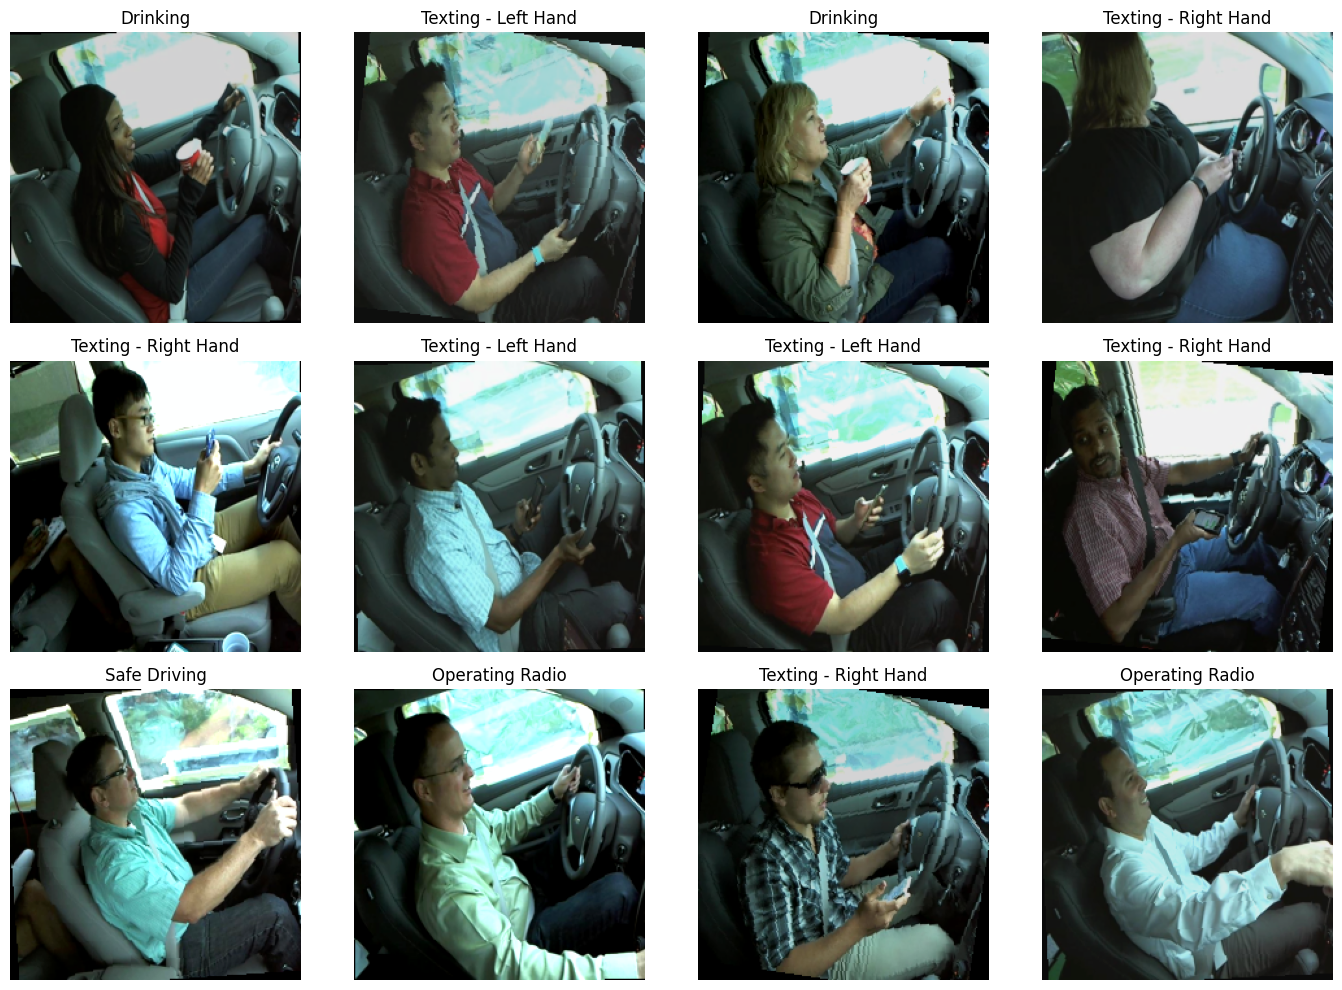

In [ ]:
# ============================================================
# CELL 25 — VISUALIZE DATA
# ============================================================

images, labels = next(
    iter(train_loader)
)

plt.figure(
    figsize=(14, 10)
)

for i in range(
    min(12, len(images))
):

    image = images[i].permute(
        1, 2, 0
    ).numpy()


    image = (
        image
        * np.array(IMAGENET_STD)
        + np.array(IMAGENET_MEAN)
    )


    image = np.clip(
        image,
        0,
        1
    )


    plt.subplot(
        3,
        4,
        i + 1
    )


    plt.imshow(
        image
    )


    plt.title(
        CLASS_NAMES[
            labels[i].item()
        ]
    )


    plt.axis(
        "off"
    )


plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CELL 26 — CLASS WEIGHTS
# ============================================================

train_counts = np.bincount(

    train_df["class_id"],

    minlength=NUM_CLASSES

)


class_weights = (

    len(train_df)

    /

    (
        NUM_CLASSES
        *
        train_counts
    )

)


class_weights = torch.tensor(

    class_weights,

    dtype=torch.float32

).to(DEVICE)


print(
    "Class weights:"
)

for i in range(NUM_CLASSES):

    print(

        f"C{i} "
        f"{CLASS_NAMES[i]:25s} "
        f"{class_weights[i].item():.4f}"

    )

Class weights:
C0 Safe Driving              0.9010
C1 Texting - Right Hand      0.9889
C2 Phone Call - Right Hand   0.9681
C3 Texting - Left Hand       0.9557
C4 Phone Call - Left Hand    0.9639
C5 Operating Radio           0.9702
C6 Drinking                  0.9645
C7 Reaching Behind           1.1198
C8 Hair / Makeup             1.1733
C9 Talking to Passenger      1.0534


In [ ]:
# ============================================================
# CELL 27 — RESNET18 TRANSFER LEARNING
# ============================================================

weights = (
    models.ResNet18_Weights.DEFAULT
)


model = models.resnet18(
    weights=weights
)


# Freeze pretrained backbone
for param in model.parameters():

    param.requires_grad = False


# Replace classifier
in_features = (
    model.fc.in_features
)


model.fc = nn.Linear(

    in_features,

    NUM_CLASSES

)


model = model.to(
    DEVICE
)


print(
    "ResNet18 loaded."
)

print(
    "Output classes:",
    NUM_CLASSES
)

ResNet18 loaded.
Output classes: 10


In [ ]:
# ============================================================
# CELL 28 — LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss(

    weight=class_weights

)

print(
    criterion
)

CrossEntropyLoss()


In [ ]:
# ============================================================
# CELL 29 — CLASSIFIER HEAD OPTIMIZER
# ============================================================

optimizer = optim.AdamW(

    model.fc.parameters(),

    lr=HEAD_LR,

    weight_decay=WEIGHT_DECAY

)


scheduler = (
    optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=0.5,

        patience=2

    )
)


print(
    "Stage 1 optimizer ready."
)

Stage 1 optimizer ready.


In [ ]:
# ============================================================
# CELL 30 — TRAINING FUNCTION
# ============================================================

def train_one_epoch(

    model,

    loader,

    criterion,

    optimizer,

    device

):

    model.train()


    running_loss = 0.0

    all_predictions = []

    all_targets = []


    for images, labels in tqdm(

        loader,

        desc="Training",

        leave=False

    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad()


        outputs = model(
            images
        )


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()


        optimizer.step()


        running_loss += (

            loss.item()
            *
            images.size(0)

        )


        predictions = torch.argmax(

            outputs,

            dim=1

        )


        all_predictions.extend(

            predictions
            .detach()
            .cpu()
            .numpy()

        )


        all_targets.extend(

            labels
            .detach()
            .cpu()
            .numpy()

        )


    loss = (

        running_loss
        /
        len(loader.dataset)

    )


    accuracy = accuracy_score(

        all_targets,

        all_predictions

    )


    precision, recall, f1, _ = (

        precision_recall_fscore_support(

            all_targets,

            all_predictions,

            average="macro",

            zero_division=0

        )

    )


    return (
        loss,
        accuracy,
        precision,
        recall,
        f1
    )

In [ ]:
# ============================================================
# CELL 31 — EVALUATION FUNCTION
# ============================================================

def evaluate(

    model,

    loader,

    criterion,

    device

):

    model.eval()


    running_loss = 0.0

    all_predictions = []

    all_targets = []


    with torch.no_grad():

        for images, labels in tqdm(

            loader,

            desc="Evaluating",

            leave=False

        ):

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            outputs = model(
                images
            )


            loss = criterion(
                outputs,
                labels
            )


            running_loss += (

                loss.item()
                *
                images.size(0)

            )


            predictions = torch.argmax(

                outputs,

                dim=1

            )


            all_predictions.extend(

                predictions
                .cpu()
                .numpy()

            )


            all_targets.extend(

                labels
                .cpu()
                .numpy()

            )


    loss = (

        running_loss
        /
        len(loader.dataset)

    )


    accuracy = accuracy_score(

        all_targets,

        all_predictions

    )


    precision, recall, f1, _ = (

        precision_recall_fscore_support(

            all_targets,

            all_predictions,

            average="macro",

            zero_division=0

        )

    )


    return (

        loss,

        accuracy,

        precision,

        recall,

        f1,

        np.array(all_targets),

        np.array(all_predictions)

    )

In [ ]:
# ============================================================
# CELL 31 — EVALUATION FUNCTION
# ============================================================

def evaluate(

    model,

    loader,

    criterion,

    device

):

    model.eval()


    running_loss = 0.0

    all_predictions = []

    all_targets = []


    with torch.no_grad():

        for images, labels in tqdm(

            loader,

            desc="Evaluating",

            leave=False

        ):

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            outputs = model(
                images
            )


            loss = criterion(
                outputs,
                labels
            )


            running_loss += (

                loss.item()
                *
                images.size(0)

            )


            predictions = torch.argmax(

                outputs,

                dim=1

            )


            all_predictions.extend(

                predictions
                .cpu()
                .numpy()

            )


            all_targets.extend(

                labels
                .cpu()
                .numpy()

            )


    loss = (

        running_loss
        /
        len(loader.dataset)

    )


    accuracy = accuracy_score(

        all_targets,

        all_predictions

    )


    precision, recall, f1, _ = (

        precision_recall_fscore_support(

            all_targets,

            all_predictions,

            average="macro",

            zero_division=0

        )

    )


    return (

        loss,

        accuracy,

        precision,

        recall,

        f1,

        np.array(all_targets),

        np.array(all_predictions)

    )

In [ ]:
# ============================================================
# CELL 32 — TRAIN CLASSIFIER HEAD
# ============================================================

history = []

best_val_f1 = 0.0

patience_counter = 0

PATIENCE = 5


for epoch in range(
    HEAD_EPOCHS
):

    print(
        f"\nEpoch "
        f"{epoch + 1}/{HEAD_EPOCHS}"
    )


    (
        train_loss,
        train_acc,
        train_precision,
        train_recall,
        train_f1

    ) = train_one_epoch(

        model,

        train_loader,

        criterion,

        optimizer,

        DEVICE

    )


    (
        val_loss,
        val_acc,
        val_precision,
        val_recall,
        val_f1,
        _,
        _

    ) = evaluate(

        model,

        val_loader,

        criterion,

        DEVICE

    )


    scheduler.step(
        val_f1
    )


    print(

        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train F1: {train_f1:.4f}"

    )


    print(

        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f}"

    )


    history.append({

        "epoch": len(history) + 1,

        "train_loss": train_loss,

        "train_accuracy": train_acc,

        "train_f1": train_f1,

        "val_loss": val_loss,

        "val_accuracy": val_acc,

        "val_f1": val_f1

    })


    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(

            model.state_dict(),

            BEST_MODEL_PATH

        )

        patience_counter = 0

        print(
            "✓ Best model saved."
        )


    else:

        patience_counter += 1


Epoch 1/3


Training:   0%|          | 0/561 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/71 [00:00<?, ?it/s]

Train Loss: 2.1399 | Train Acc: 0.2599 | Train F1: 0.2556
Val Loss: 1.9706 | Val Acc: 0.4295 | Val F1: 0.4120
✓ Best model saved.

Epoch 2/3


Training:   0%|          | 0/561 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/71 [00:00<?, ?it/s]

Train Loss: 1.8435 | Train Acc: 0.4805 | Train F1: 0.4717
Val Loss: 1.7220 | Val Acc: 0.5482 | Val F1: 0.5346
✓ Best model saved.

Epoch 3/3


Training:   0%|          | 0/561 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/71 [00:00<?, ?it/s]

Train Loss: 1.6362 | Train Acc: 0.5751 | Train F1: 0.5672
Val Loss: 1.5282 | Val Acc: 0.6383 | Val F1: 0.6144
✓ Best model saved.


In [ ]:
# ============================================================
# CELL 33 — UNFREEZE RESNET18 LAYER4
# ============================================================

for param in model.layer4.parameters():

    param.requires_grad = True


optimizer = optim.AdamW(

    filter(

        lambda p:
        p.requires_grad,

        model.parameters()

    ),

    lr=BACKBONE_LR,

    weight_decay=WEIGHT_DECAY

)


scheduler = (
    optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=0.5,

        patience=2

    )
)


print(
    "Layer4 is now trainable."
)

print(
    "Fine-tuning learning rate:",
    BACKBONE_LR
)

Layer4 is now trainable.
Fine-tuning learning rate: 1e-05


In [ ]:
# ============================================================
# CELL 34 — FINE-TUNE MODEL
# ============================================================
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch

# 1. Initialize ReduceLROnPlateau
# mode='max' because we are monitoring val_f1 (higher is better)
# factor=0.5 cuts the learning rate in half when plateaued
# patience=2 waits 2 epochs without improvement before reducing LR
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

# 2. Initialize Early Stopping Parameters
PATIENCE = 5 # Epochs to wait for an improvement before stopping entirely
patience_counter = 0
best_val_f1 = 0.0 # Track the best metric

for epoch in range(FINETUNE_EPOCHS):
    print(f"\nFine-tuning Epoch {epoch + 1}/{FINETUNE_EPOCHS}")

    # Train phase
    (
        train_loss, train_acc, train_precision, train_recall, train_f1
    ) = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Validation phase
    (
        val_loss, val_acc, val_precision, val_recall, val_f1, _, _
    ) = evaluate(model, val_loader, criterion, DEVICE)

    # 3. Step the scheduler based on the validation metric
    scheduler.step(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    history.append({
        "epoch": len(history) + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_f1": val_f1
    })

    # 4. Early Stopping and Checkpointing Logic
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        patience_counter = 0
        print("✓ New best model saved.")
    else:
        patience_counter += 1
        print(f"No improvement. Early stopping counter: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered after {epoch + 1} epochs.")
        break


Fine-tuning Epoch 1/20


Training:   0%|          | 0/561 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/71 [00:00<?, ?it/s]

Train Loss: 0.2050 | Train Acc: 0.9663 | Train F1: 0.9657
Val Loss: 0.1208 | Val Acc: 0.9786 | Val F1: 0.9782
✓ New best model saved.

Fine-tuning Epoch 2/20


Training:   0%|          | 0/561 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/71 [00:00<?, ?it/s]

Train Loss: 0.0021 | Train Acc: 0.9998 | Train F1: 0.9998
Val Loss: 0.0133 | Val Acc: 0.9973 | Val F1: 0.9973
✓ New best model saved.

Fine-tuning Epoch 20/20


Training:   0%|          | 0/561 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/71 [00:00<?, ?it/s]

Train Loss: 0.0018 | Train Acc: 1.0000 | Train F1: 1.0000
Val Loss: 0.0123 | Val Acc: 0.9969 | Val F1: 0.9968
No improvement. Early stopping counter: 1/5


In [ ]:
# ============================================================
# CELL 35 — TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)

display(
    history_df
)

,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1
0,1,2.139889,0.259936,0.255583,1.970588,0.429527,0.411965
1,2,1.843521,0.480517,0.471688,1.722044,0.548171,0.534579
2,3,1.636184,0.575060,0.567240,1.528161,0.638269,0.614442
3,4,0.750718,0.854284,0.848908,0.306152,0.946922,0.945089
4,5,0.205028,0.966330,0.965746,0.120762,0.978591,0.978183
5,6,0.109754,0.983332,0.983042,0.075148,0.984835,0.984591
6,7,0.070757,0.988126,0.987992,0.049791,0.989295,0.989129
7,8,0.047905,0.992252,0.992220,0.038309,0.992864,0.992679
8,9,0.033877,0.995373,0.995352,0.032124,0.992864,0.992690
9,10,0.027145,0.995652,0.995576,0.026719,0.994648,0.994574


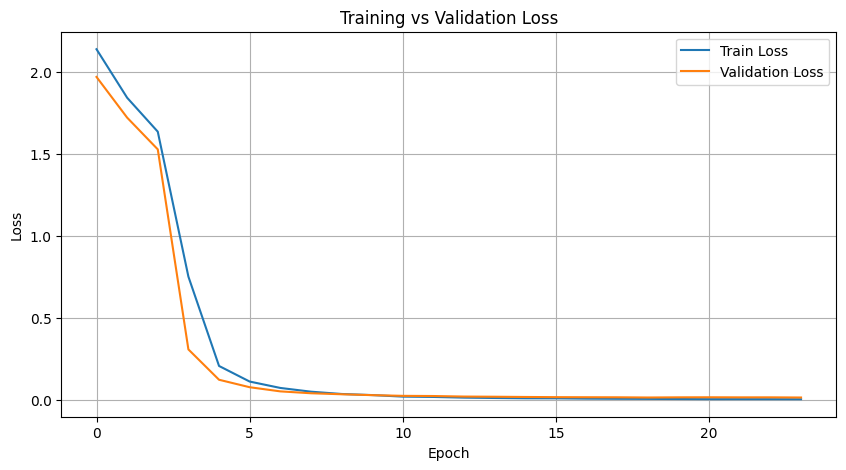

In [ ]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid()

plt.show()

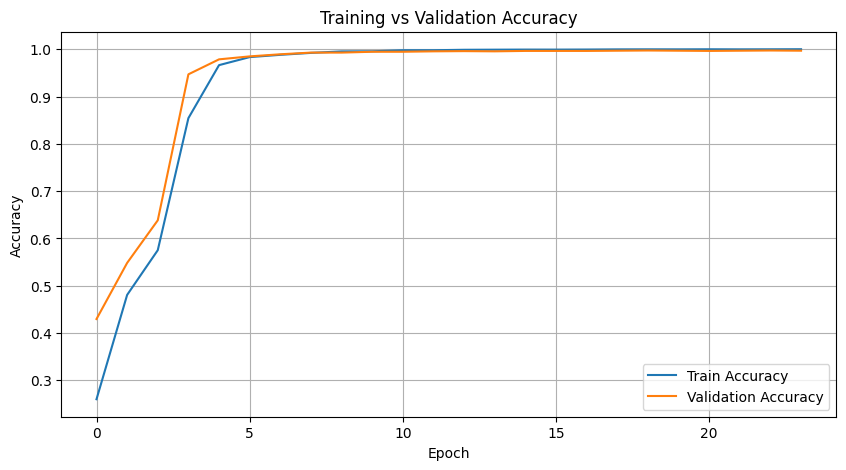

In [ ]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid()

plt.show()

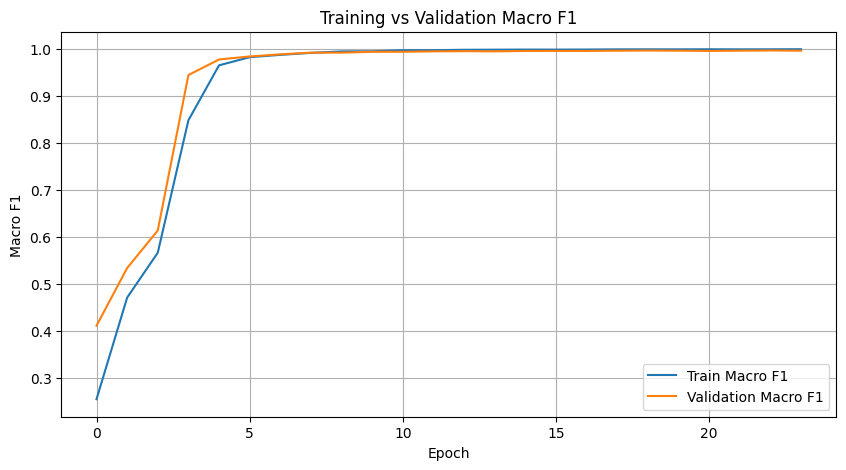

In [ ]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["train_f1"],
    label="Train Macro F1"
)

plt.plot(
    history_df["val_f1"],
    label="Validation Macro F1"
)

plt.xlabel("Epoch")

plt.ylabel("Macro F1")

plt.title(
    "Training vs Validation Macro F1"
)

plt.legend()

plt.grid()

plt.show()

In [ ]:
# ============================================================
# CELL 36 — LOAD BEST CHECKPOINT
# ============================================================

model.load_state_dict(

    torch.load(

        BEST_MODEL_PATH,

        map_location=DEVICE

    )

)

model = model.to(
    DEVICE
)

model.eval()

print(
    "Best model loaded."
)

print(
    "Best validation Macro F1:",
    best_val_f1
)

Best model loaded.
Best validation Macro F1: 0.9973345366765646


In [ ]:
# ============================================================
# CELL 37 — FINAL TEST EVALUATION
# ============================================================

(
    test_loss,
    test_accuracy,
    test_precision,
    test_recall,
    test_f1,
    test_targets,
    test_predictions

) = evaluate(

    model,

    test_loader,

    criterion,

    DEVICE

)


print(
    "\n================================"
)

print(
    "FINAL DRIVER DISTRACTION RESULTS"
)

print(
    "================================"
)


print(
    f"Test Loss       : {test_loss:.4f}"
)

print(
    f"Test Accuracy   : {test_accuracy:.4f}"
)

print(
    f"Macro Precision : {test_precision:.4f}"
)

print(
    f"Macro Recall    : {test_recall:.4f}"
)

print(
    f"Macro F1        : {test_f1:.4f}"
)

Evaluating:   0%|          | 0/71 [00:00<?, ?it/s]


FINAL DRIVER DISTRACTION RESULTS
Test Loss       : 0.0088
Test Accuracy   : 0.9978
Macro Precision : 0.9978
Macro Recall    : 0.9977
Macro F1        : 0.9978


In [66]:
# ============================================================
# CELL 38 — CLASSIFICATION REPORT
# ============================================================

print(

    classification_report(

        test_targets,

        test_predictions,

        labels=list(
            range(NUM_CLASSES)
        ),

        target_names=CLASS_NAMES,

        digits=4,

        zero_division=0

    )

)

                         precision    recall  f1-score   support

           Safe Driving     1.0000    0.9960    0.9980       249
   Texting - Right Hand     1.0000    1.0000    1.0000       226
Phone Call - Right Hand     1.0000    0.9914    0.9957       232
    Texting - Left Hand     1.0000    1.0000    1.0000       235
 Phone Call - Left Hand     1.0000    1.0000    1.0000       233
        Operating Radio     0.9957    1.0000    0.9978       231
               Drinking     0.9873    1.0000    0.9936       233
        Reaching Behind     1.0000    1.0000    1.0000       200
          Hair / Makeup     0.9948    0.9948    0.9948       191
   Talking to Passenger     1.0000    0.9953    0.9976       213

               accuracy                         0.9978      2243
              macro avg     0.9978    0.9977    0.9978      2243
           weighted avg     0.9978    0.9978    0.9978      2243



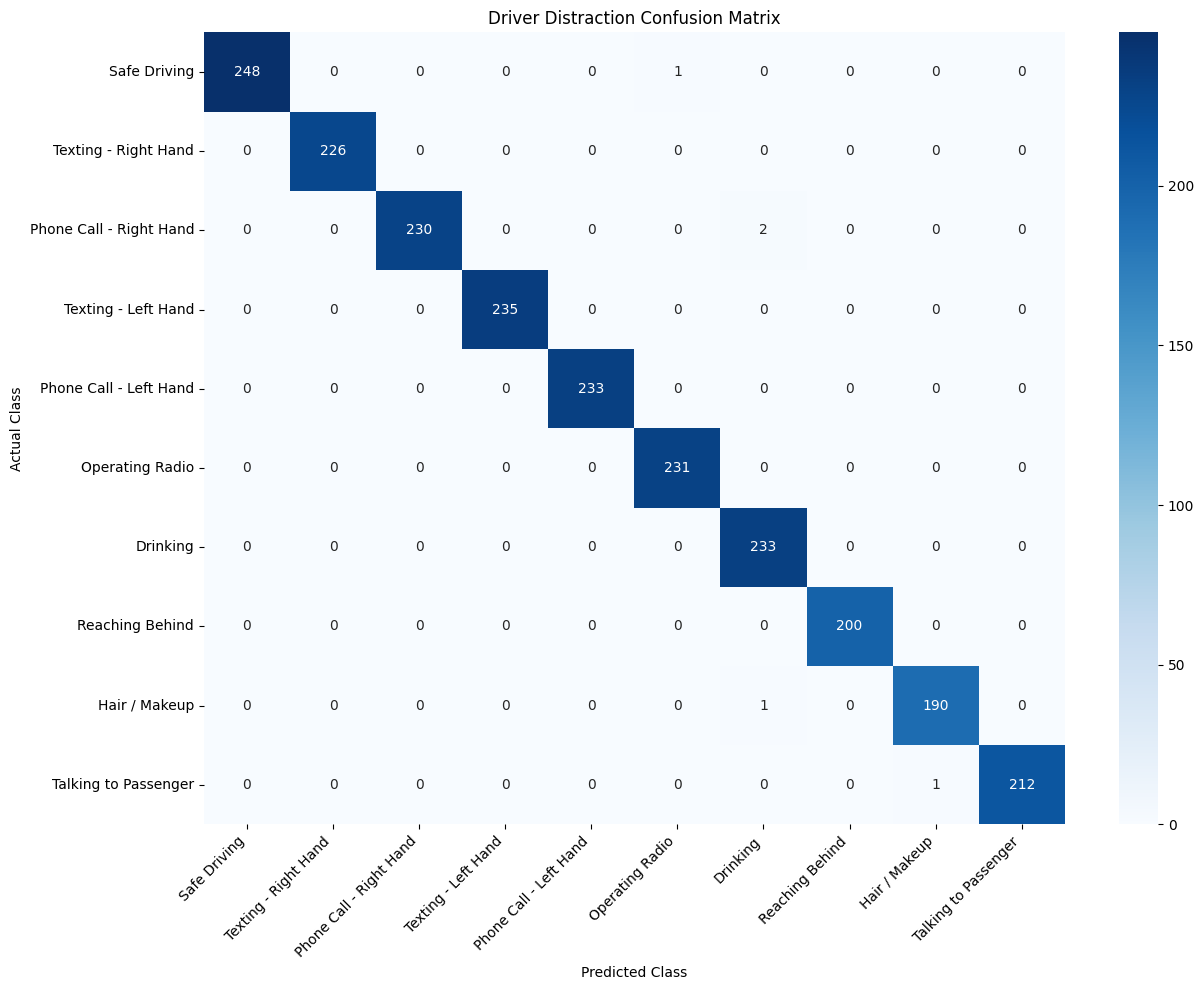

In [67]:
# ============================================================
# CELL 39 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    test_targets,

    test_predictions,

    labels=list(
        range(NUM_CLASSES)
    )

)


plt.figure(
    figsize=(13, 10)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES

)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    "Driver Distraction Confusion Matrix"
)


plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)


plt.tight_layout()

plt.show()

In [69]:
# ============================================================
# CELL 40 — PER CLASS PERFORMANCE
# ============================================================

precision, recall, f1, support = (

    precision_recall_fscore_support(

        test_targets,

        test_predictions,

        labels=list(
            range(NUM_CLASSES)
        ),

        zero_division=0

    )

)


per_class_results = pd.DataFrame({

    "Class ID":
        range(NUM_CLASSES),

    "Class":
        CLASS_NAMES,

    "Precision":
        precision,

    "Recall":
        recall,

    "F1":
        f1,

    "Support":
        support

})


display(
    per_class_results.round(4)
)

,Class ID,Class,Precision,Recall,F1,Support
0,0,Safe Driving,1.0000,0.9960,0.9980,249
1,1,Texting - Right Hand,1.0000,1.0000,1.0000,226
2,2,Phone Call - Right Hand,1.0000,0.9914,0.9957,232
3,3,Texting - Left Hand,1.0000,1.0000,1.0000,235
4,4,Phone Call - Left Hand,1.0000,1.0000,1.0000,233
5,5,Operating Radio,0.9957,1.0000,0.9978,231
6,6,Drinking,0.9873,1.0000,0.9936,233
7,7,Reaching Behind,1.0000,1.0000,1.0000,200
8,8,Hair / Makeup,0.9948,0.9948,0.9948,191
9,9,Talking to Passenger,1.0000,0.9953,0.9976,213


In [70]:
# ============================================================
# CELL 41 — SAVE COMPLETE MODEL
# ============================================================

checkpoint = {

    "model_state_dict":
        model.state_dict(),

    "class_names":
        CLASS_NAMES,

    "image_size":
        IMAGE_SIZE,

    "num_classes":
        NUM_CLASSES,

    "test_accuracy":
        test_accuracy,

    "test_macro_f1":
        test_f1,

    "best_validation_macro_f1":
        best_val_f1

}


FINAL_MODEL_PATH = (
    "/content/"
    "driver_distraction_resnet18_complete.pth"
)


torch.save(

    checkpoint,

    FINAL_MODEL_PATH

)


print(
    "Saved model:"
)

print(
    FINAL_MODEL_PATH
)

Saved model:
/content/driver_distraction_resnet18_complete.pth


In [71]:
# ============================================================
# CELL 42 — SINGLE IMAGE PREDICTION
# ============================================================

def predict_image(
    image_path,
    model,
    transform,
    device
):

    model.eval()


    image = Image.open(
        image_path
    ).convert(
        "RGB"
    )


    tensor = transform(
        image
    ).unsqueeze(
        0
    ).to(
        device
    )


    with torch.no_grad():

        outputs = model(
            tensor
        )

        probabilities = (
            torch.softmax(
                outputs,
                dim=1
            )[0]
        )


    confidence, predicted_class = (
        torch.max(
            probabilities,
            dim=0
        )
    )


    return (

        predicted_class.item(),

        confidence.item(),

        probabilities
        .cpu()
        .numpy()

    )

In [72]:
# ============================================================
# CELL 43 — TEST SINGLE IMAGE
# ============================================================

IMAGE_PATH = (
    test_df.iloc[0]["path"]
)


predicted_class, confidence, probabilities = (

    predict_image(

        IMAGE_PATH,

        model,

        val_transform,

        DEVICE

    )

)


print(
    "Actual:"
)

print(
    CLASS_NAMES[
        int(
            test_df.iloc[0]["class_id"]
        )
    ]
)


print(
    "\nPredicted:"
)

print(
    CLASS_NAMES[
        predicted_class
    ]
)


print(
    "\nConfidence:"
)

print(
    f"{confidence * 100:.2f}%"
)

Actual:
Phone Call - Left Hand

Predicted:
Phone Call - Left Hand

Confidence:
99.99%


In [73]:
# ============================================================
# CELL 44 — DISTRACTION STATUS
# ============================================================

def get_distraction_status(
    predicted_class,
    confidence,
    threshold=0.75
):

    if confidence < threshold:

        return "UNCERTAIN"


    if predicted_class == 0:

        return "NOT DISTRACTED"


    return "DISTRACTED"


status = get_distraction_status(

    predicted_class,

    confidence,

    threshold=0.75

)


print(
    "Behavior:",
    CLASS_NAMES[predicted_class]
)

print(
    "Confidence:",
    f"{confidence * 100:.2f}%"
)

print(
    "Status:",
    status
)

Behavior: Phone Call - Left Hand
Confidence: 99.99%
Status: DISTRACTED


In [74]:
# ============================================================
# CELL 45 — TOP 3 PREDICTIONS
# ============================================================

top_values, top_indices = torch.topk(

    torch.tensor(
        probabilities
    ),

    k=3

)


for rank, (
    probability,
    class_index
) in enumerate(

    zip(
        top_values,
        top_indices
    ),

    start=1

):

    print(

        f"{rank}. "
        f"{CLASS_NAMES[class_index.item()]} "
        f"— "
        f"{probability.item() * 100:.2f}%"

    )

1. Phone Call - Left Hand — 99.99%
2. Texting - Left Hand — 0.00%
3. Drinking — 0.00%


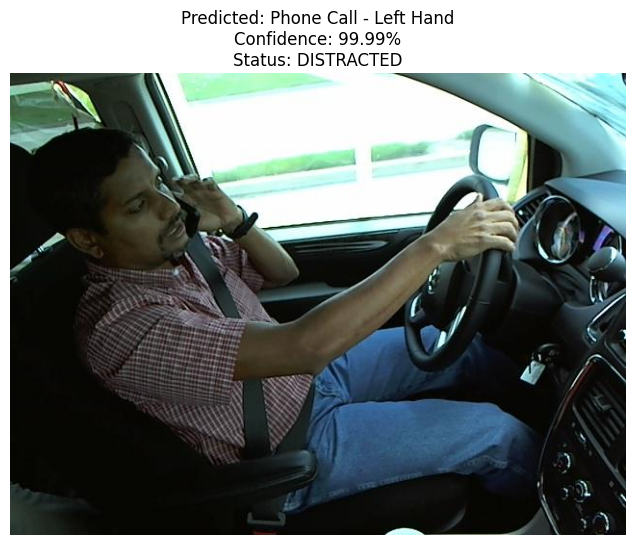

In [76]:
# ============================================================
# CELL 46 — DISPLAY PREDICTION
# ============================================================

image = Image.open(
    IMAGE_PATH
).convert(
    "RGB"
)


plt.figure(
    figsize=(8, 6)
)


plt.imshow(
    image
)


plt.title(

    f"Predicted: "
    f"{CLASS_NAMES[predicted_class]}\n"

    f"Confidence: "
    f"{confidence * 100:.2f}%\n"

    f"Status: {status}"

)


plt.axis(
    "off"
)


plt.show()

In [78]:
# ============================================================
# CELL 47 — TEMPORAL SMOOTHING
# ============================================================

from collections import deque


prediction_history = deque(
    maxlen=5
)


def update_prediction_history(

    predicted_class,

    confidence,

    confidence_threshold=0.75

):

    if (
        confidence
        >= confidence_threshold
    ):

        prediction_history.append(
            predicted_class
        )

    else:

        prediction_history.append(
            -1
        )


    valid = [

        x
        for x in prediction_history
        if x != -1

    ]


    if len(valid) < 3:

        return None


    counts = Counter(
        valid
    )


    dominant_class, count = (
        counts.most_common(1)[0]
    )


    if count >= 3:

        return dominant_class


    return None